data

In [11]:
from pathlib import Path

DATA_DIR = Path("open-problems-single-cell-perturbations")

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("open-problems-single-cell-perturbations")

# Core files
de_train = pd.read_parquet(DATA_DIR / "de_train.parquet")
id_map = pd.read_csv(DATA_DIR / "id_map.csv")
adata_train = pd.read_parquet(DATA_DIR / "adata_train.parquet")
adata_obs_meta = pd.read_csv(DATA_DIR / "adata_obs_meta.csv")
multiome_obs_meta = pd.read_csv(DATA_DIR / "multiome_obs_meta.csv")
multiome_var_meta = pd.read_csv(DATA_DIR / "multiome_var_meta.csv")

print("de_train shape:", de_train.shape)
print("id_map shape:", id_map.shape)
print("adata_train shape:", adata_train.shape)
print("adata_obs_meta shape:", adata_obs_meta.shape)
print("multiome_obs_meta shape:", multiome_obs_meta.shape)
print("multiome_var_meta shape:", multiome_var_meta.shape)

display(de_train.iloc[:5, :12])
display(id_map.head())
display(adata_train.head())
display(adata_obs_meta.head())
display(multiome_obs_meta.head())
display(multiome_var_meta.head())

de_train shape: (614, 18216)
id_map shape: (255, 3)
adata_train shape: (416442312, 4)
adata_obs_meta shape: (240090, 15)
multiome_obs_meta shape: (25551, 3)
multiome_var_meta shape: (158205, 5)


,cell_type,sm_name,sm_lincs_id,SMILES,control,A1BG,A1BG-AS1,A2M,A2M-AS1,A2MP1,A4GALT,AAAS
0,NK cells,Clotrimazole,LSM-5341,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,False,0.104720,-0.077524,-1.625596,-0.144545,0.143555,0.073229,-0.016823
1,T cells CD4+,Clotrimazole,LSM-5341,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,False,0.915953,-0.884380,0.371834,-0.081677,-0.498266,0.203559,0.604656
2,T cells CD8+,Clotrimazole,LSM-5341,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,False,-0.387721,-0.305378,0.567777,0.303895,-0.022653,-0.480681,0.467144
3,T regulatory cells,Clotrimazole,LSM-5341,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,False,0.232893,0.129029,0.336897,0.486946,0.767661,0.718590,-0.162145
4,NK cells,Mometasone Furoate,LSM-3349,C[C@@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@]4(C)[C...,False,4.290652,-0.063864,-0.017443,-0.541154,0.570982,2.022829,0.600011


,id,cell_type,sm_name
0,0,B cells,5-(9-Isopropyl-8-methyl-2-morpholino-9H-purin-...
1,1,B cells,ABT-199 (GDC-0199)
2,2,B cells,ABT737
3,3,B cells,AMD-070 (hydrochloride)
4,4,B cells,AT 7867


,obs_id,gene,count,normalized_count
0,000006a87ba75b72,AATF,1,5.567933
1,000006a87ba75b72,ABHD12,1,5.567933
2,000006a87ba75b72,ABHD3,1,5.567933
3,000006a87ba75b72,AC004687.1,1,5.567933
4,000006a87ba75b72,AC009779.2,1,5.567933


,obs_id,library_id,plate_name,well,row,col,cell_id,donor_id,cell_type,sm_lincs_id,sm_name,SMILES,dose_uM,timepoint_hr,control
0,000006a87ba75b72,library_4,plate_4,F7,F,7,PBMC,donor_2,T cells CD4+,LSM-4944,MLN 2238,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B(O)O,1.0,24,False
1,0000233976e3cd37,library_0,plate_3,D4,D,4,PBMC,donor_1,T cells CD4+,LSM-46203,BMS-265246,CCCCOc1c(C(=O)c2c(F)cc(C)cc2F)cnc2[nH]ncc12,1.0,24,False
2,0001533c5e876362,library_2,plate_0,B11,B,11,PBMC,donor_0,T regulatory cells,LSM-45663,Resminostat,CN(C)Cc1ccc(S(=O)(=O)n2ccc(/C=C/C(=O)NO)c2)cc1,1.0,24,False
3,00022f989630d14b,library_35,plate_2,E6,E,6,PBMC,donor_0,T cells CD4+,LSM-43216,FK 866,O=C(/C=C/c1cccnc1)NCCCCC1CCN(C(=O)c2ccccc2)CC1,1.0,24,False
4,0002560bd38ce03e,library_22,plate_4,B6,B,6,PBMC,donor_2,T cells CD4+,LSM-1099,Nilotinib,Cc1cn(-c2cc(NC(=O)c3ccc(C)c(Nc4nccc(-c5cccnc5)...,1.0,24,False


,obs_id,cell_type,donor_id
0,000225c1151ab841,B cells,donor_0
1,0003c40a54367871,T cells CD4+,donor_2
2,0004bf574b822c3c,T cells CD4+,donor_2
3,000d59b5478f28e2,B cells,donor_0
4,0011b7473923d7b5,NK cells,donor_2


,location,gene_id,feature_type,genome,interval
0,A1BG,ENSG00000121410,Gene Expression,GRCh38,chr19:58353491-58353492
1,A1BG-AS1,ENSG00000268895,Gene Expression,GRCh38,chr19:58347750-58351970
2,A2M,ENSG00000175899,Gene Expression,GRCh38,chr12:9116156-9116157
3,A2M-AS1,ENSG00000245105,Gene Expression,GRCh38,chr12:9065162-9065177
4,A2ML1,ENSG00000166535,Gene Expression,GRCh38,chr12:8822620-8845004


In [13]:
metadata_cols = [
    col for col in [
        "cell_type",
        "sm_name",
        "sm_lincs_id",
        "SMILES",
        "control"
    ]
    if col in de_train.columns
]

gene_cols = [col for col in de_train.columns if col not in metadata_cols]

print("Metadata columns:")
print(metadata_cols)

print("\nNumber of gene target columns:")
print(len(gene_cols))

print("\nFirst 10 genes:")
print(gene_cols[:10])

Metadata columns:
['cell_type', 'sm_name', 'sm_lincs_id', 'SMILES', 'control']

Number of gene target columns:
18211

First 10 genes:
['A1BG', 'A1BG-AS1', 'A2M', 'A2M-AS1', 'A2MP1', 'A4GALT', 'AAAS', 'AACS', 'AAGAB', 'AAK1']


How many training combinations per cell type?

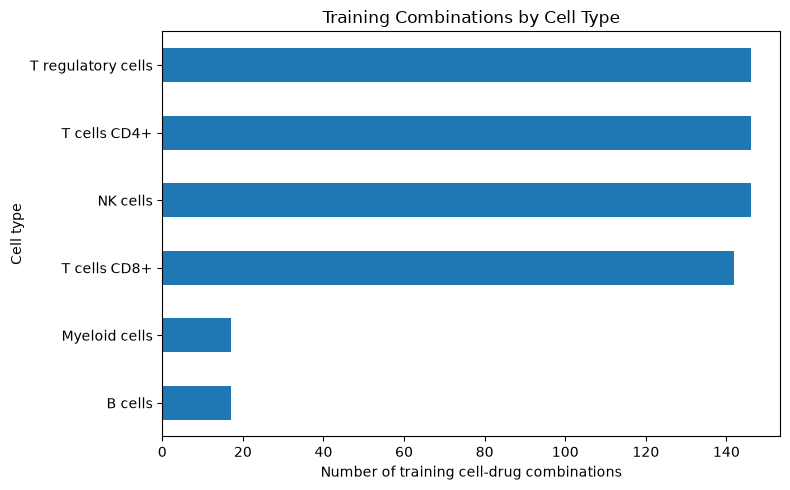

cell_type
B cells                17
Myeloid cells          17
T cells CD8+          142
NK cells              146
T cells CD4+          146
T regulatory cells    146
Name: count, dtype: int64


In [14]:
cell_counts = de_train["cell_type"].value_counts().sort_values()

plt.figure(figsize=(8, 5))
cell_counts.plot(kind="barh")

plt.xlabel("Number of training cell-drug combinations")
plt.ylabel("Cell type")
plt.title("Training Combinations by Cell Type")
plt.tight_layout()
plt.show()

print(cell_counts)

The contribution of cell types in train and test

,Train,Test
cell_type,,
B cells,17,128.0
Myeloid cells,17,127.0
NK cells,146,0.0
T cells CD4+,146,0.0
T cells CD8+,142,0.0
T regulatory cells,146,0.0


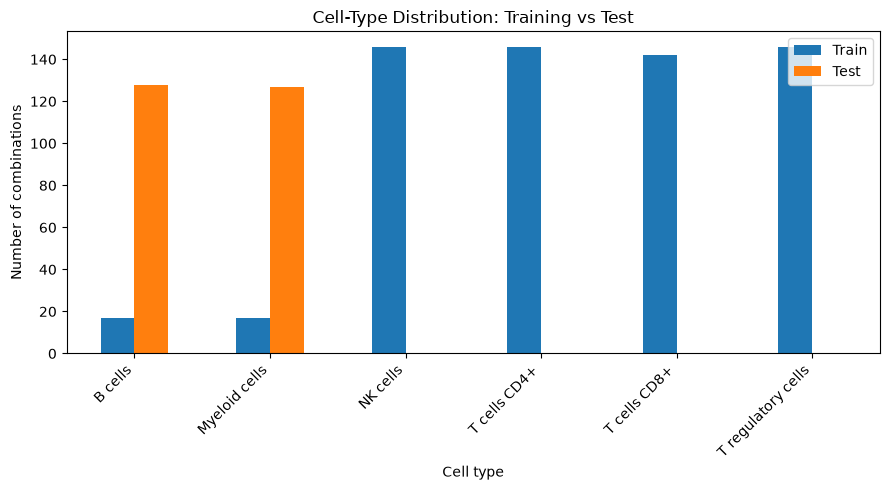

In [15]:
train_cell_counts = de_train["cell_type"].value_counts()
test_cell_counts = id_map["cell_type"].value_counts()

cell_comparison = pd.DataFrame({
    "Train": train_cell_counts,
    "Test": test_cell_counts
}).fillna(0)

display(cell_comparison)

cell_comparison.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Number of combinations")
plt.xlabel("Cell type")
plt.title("Cell-Type Distribution: Training vs Test")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Number of unique drugs in training: 146
Number of unique drugs in test: 129


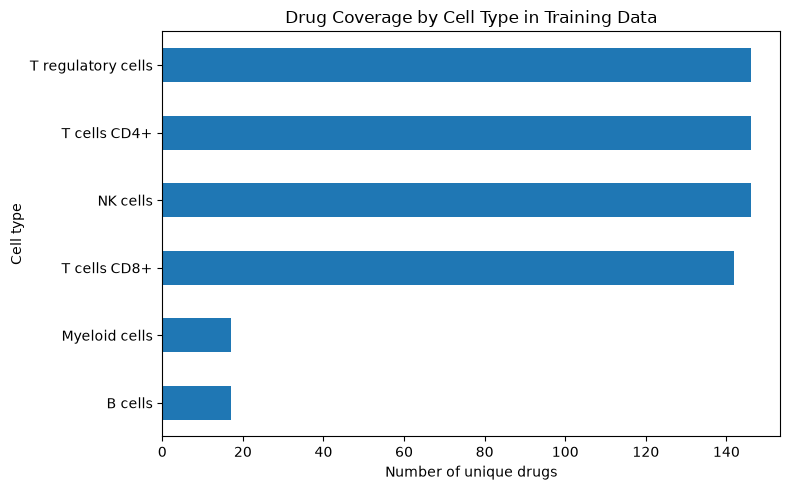

cell_type
B cells                17
Myeloid cells          17
T cells CD8+          142
NK cells              146
T cells CD4+          146
T regulatory cells    146
Name: sm_name, dtype: int64


In [16]:
print("Number of unique drugs in training:",
      de_train["sm_name"].nunique())

print("Number of unique drugs in test:",
      id_map["sm_name"].nunique())

drug_by_cell = (
    de_train
    .groupby("cell_type")["sm_name"]
    .nunique()
    .sort_values()
)

plt.figure(figsize=(8, 5))
drug_by_cell.plot(kind="barh")

plt.xlabel("Number of unique drugs")
plt.ylabel("Cell type")
plt.title("Drug Coverage by Cell Type in Training Data")
plt.tight_layout()
plt.show()

print(drug_by_cell)

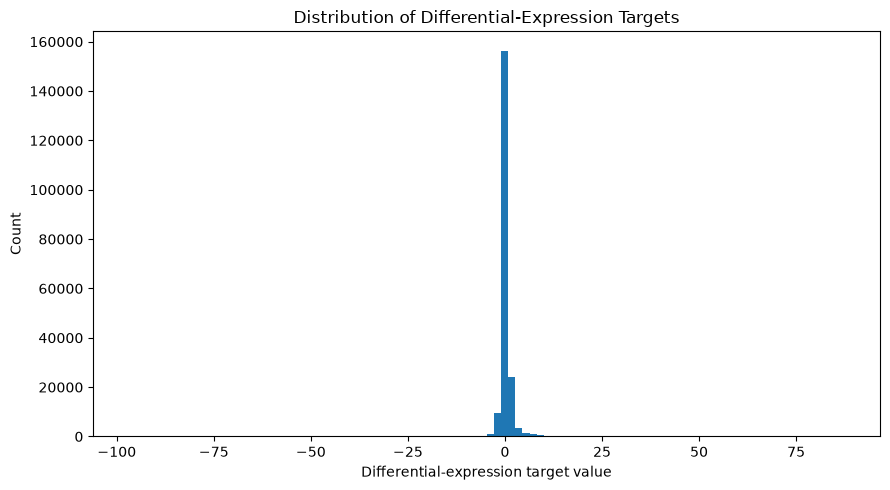

Sampled DE mean: 0.3292069298110336
Sampled DE std: 2.339052021058986
Sampled DE min: -96.85660989448851
Sampled DE max: 87.38861674444404


In [17]:
de_values = de_train[gene_cols].to_numpy().ravel()

rng = np.random.default_rng(7)

sample_size = min(200000, len(de_values))
sample_idx = rng.choice(
    len(de_values),
    size=sample_size,
    replace=False
)

de_sample = de_values[sample_idx]

plt.figure(figsize=(9, 5))
plt.hist(de_sample, bins=100)

plt.xlabel("Differential-expression target value")
plt.ylabel("Count")
plt.title("Distribution of Differential-Expression Targets")
plt.tight_layout()
plt.show()

print("Sampled DE mean:", de_sample.mean())
print("Sampled DE std:", de_sample.std())
print("Sampled DE min:", de_sample.min())
print("Sampled DE max:", de_sample.max())

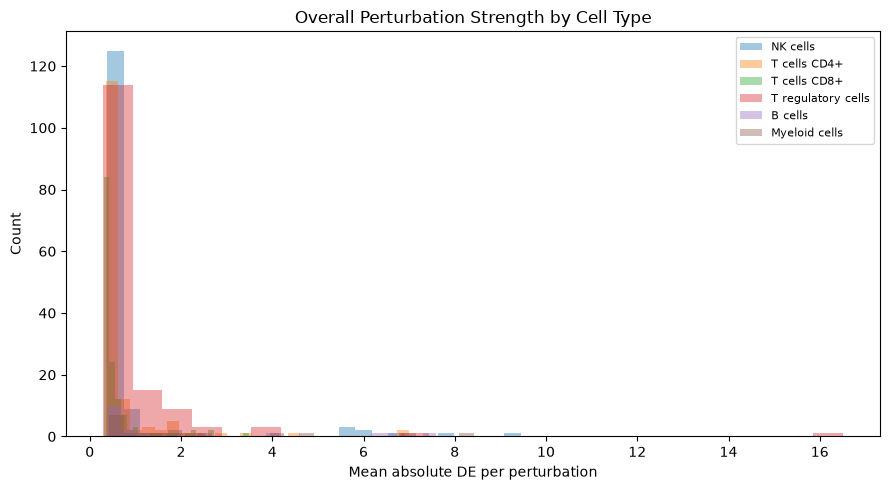

In [18]:
de_matrix = de_train[gene_cols].to_numpy()

row_mean_abs = np.mean(np.abs(de_matrix), axis=1)

summary_df = de_train[["cell_type", "sm_name"]].copy()
summary_df["mean_abs_DE"] = row_mean_abs

plt.figure(figsize=(9, 5))

for cell_type in summary_df["cell_type"].unique():
    values = summary_df.loc[
        summary_df["cell_type"] == cell_type,
        "mean_abs_DE"
    ]

    plt.hist(
        values,
        bins=25,
        alpha=0.4,
        label=cell_type
    )

plt.xlabel("Mean absolute DE per perturbation")
plt.ylabel("Count")
plt.title("Overall Perturbation Strength by Cell Type")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

cell-type effect?

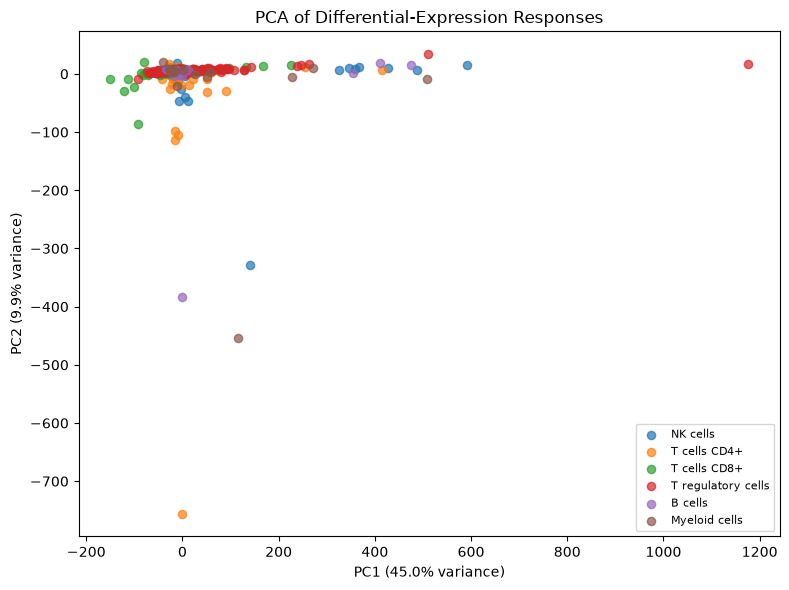

Variance explained by first 2 PCs: 0.5489227928904009


In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_de = de_train[gene_cols].to_numpy()

# Each gene can have very different scales, so standardize first.
X_scaled = StandardScaler().fit_transform(X_de)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cell_type": de_train["cell_type"].values,
    "sm_name": de_train["sm_name"].values
})

plt.figure(figsize=(8, 6))

for cell_type in pca_df["cell_type"].unique():
    subset = pca_df[pca_df["cell_type"] == cell_type]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=cell_type,
        alpha=0.7,
        s=35
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)
plt.title("PCA of Differential-Expression Responses")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(
    "Variance explained by first 2 PCs:",
    pca.explained_variance_ratio_.sum()
)

In [20]:
train_drugs = set(de_train["sm_name"].unique())
test_drugs = set(id_map["sm_name"].unique())

overlap = train_drugs & test_drugs
test_only = test_drugs - train_drugs

print("Unique train drugs:", len(train_drugs))
print("Unique test drugs:", len(test_drugs))
print("Drugs appearing in both:", len(overlap))
print("Test-only drugs:", len(test_only))

print("\nExample overlapping drugs:")
print(list(overlap)[:10])

print("\nExample test-only drugs:")
print(list(test_only)[:10])

Unique train drugs: 146
Unique test drugs: 129
Drugs appearing in both: 129
Test-only drugs: 0

Example overlapping drugs:
['Cabozantinib', 'Trametinib', 'MK-5108', 'Ixabepilone', 'Quizartinib', 'TPCA-1', 'Raloxifene', 'Phenylbutazone', 'YK 4-279', 'TIE2 Kinase Inhibitor']

Example test-only drugs:
[]
